Let's make a signal with two changepoints:

- Mean shift at `t=100`
- Variance shift at `t=200`

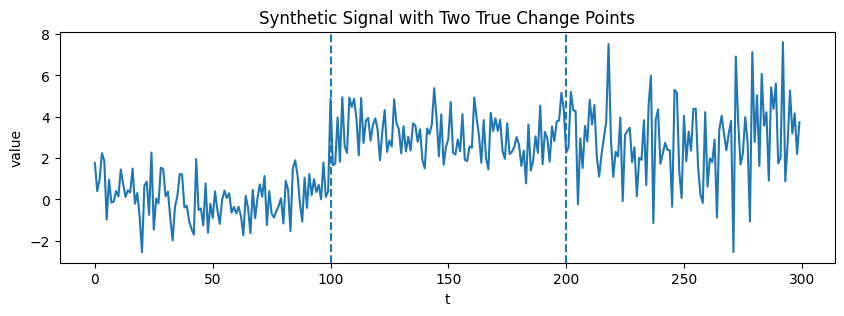

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

n1, n2, n3 = 100, 100, 100

seg1 = np.random.normal(0, 1, n1)
seg2 = np.random.normal(3, 1, n2)
seg3 = np.random.normal(3, 2, n3)

x = np.concatenate([seg1, seg2, seg3])

plt.figure(figsize=(10,3))
plt.plot(x)
plt.axvline(n1, linestyle='--')
plt.axvline(n1+n2, linestyle='--')
plt.xlabel('t')
plt.ylabel('value')
plt.title("Synthetic Signal with Two True Change Points")
plt.show()

## DeCon

We will compare the distribution before and after each candidate split. This is not full DeCon in its most general form, but it establishes the core idea clearly. For each candidate split $t$ we calculate the *absolute difference of means*: $D(t)$:

\begin{equation}
D(t) = |\mu_{1:t}-\mu_{t+1:n}| = |\mu_R - \mu_L|
\end{equation}

We ignore very small segments to avoid instability. 

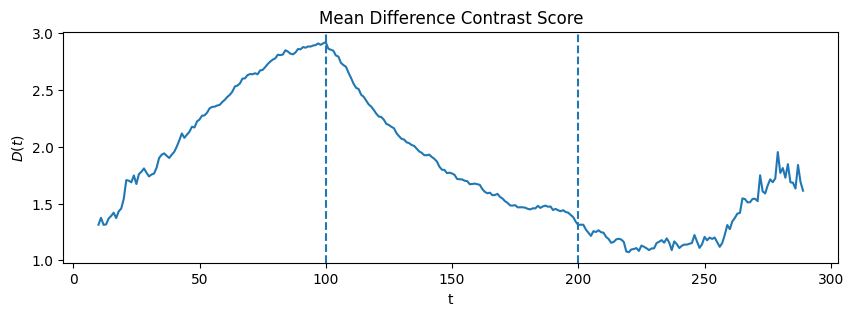

In [9]:
scores = []
ts = range(10, len(x)-10)

for t in ts:
    left = x[:t]
    right = x[t:]
    
    score = abs(np.mean(left) - np.mean(right))
    scores.append(score)

scores = np.array(scores)

plt.figure(figsize=(10,3))
plt.plot(ts, scores)
plt.axvline(n1, linestyle='--')
plt.axvline(n1+n2, linestyle='--')
plt.xlabel('t')
plt.ylabel(r'$D(t)$')
plt.title("Mean Difference Contrast Score")
plt.show()

In [12]:
np.argmin(scores)

np.int64(210)

We observe a strong peak near `t=100` and a much weaker or barely visible signal near `t=200`. That is because this method only detects mean shifts. The second change point involves *variance change* but no *mean change*, so it is almost invisible to this statistic. Let's add the variance in the mix:

\begin{equation}
D(t) = |\mu_L - \mu_R| + |\sigma_L - \sigma_R|
\end{equation}


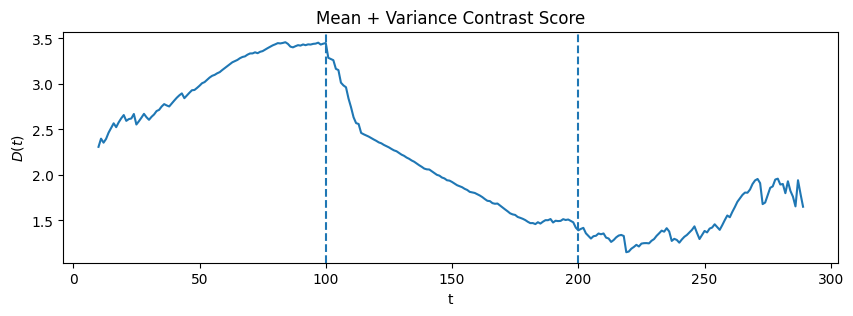

In [13]:
scores_mv = []
ts = range(10, len(x)-10)

for t in ts:
    left = x[:t]
    right = x[t:]
    
    mean_diff = abs(np.mean(left) - np.mean(right))
    std_diff  = abs(np.std(left)  - np.std(right))
    
    score = mean_diff + std_diff
    scores_mv.append(score)

scores_mv = np.array(scores_mv)

plt.figure(figsize=(10,3))
plt.plot(ts, scores_mv)
plt.axvline(n1, linestyle='--')
plt.axvline(n1+n2, linestyle='--')
plt.xlabel('t')
plt.ylabel(r'$D(t)$')
plt.title("Mean + Variance Contrast Score")
plt.show()

In [15]:
np.argmax(scores_mv)

np.int64(74)

Now we see a somewhat clearer change around $t=200$, but still nothing very much. This is actually a phenomenon that will haunt us during this notebook.

We should of course get the change points from `scores_mv`. But if you do `np.argmax(scores_mv)`, you're likely to get a number well below 100. Can you think why that is...? 

This is actually a classical issue with [single-split scanning](https://www.tandfonline.com/doi/full/10.1080/01621459.2025.2563777).  You see that change point detection is not merely about computing a statistic – it is about how the statistic interacts with segmentation structure. 

## E-divisive

The next algorithm we discuss is E-divisive, which is based on energy statistics. This algorithm uses [energy distance](https://en.wikipedia.org/wiki/Energy_distance): a measurement of how different two distributions are in a nonparametric way, using all pairwise distances.

The idea is:

1. For each candidate split $t$, compute the energy distance $\epsilon$ between the left segment $L=x_{1:t}$ and the right segment $R=x_{t+1:n}$.
2. Pick the split that maximises $\epsilon$.
3. For multiple change points, recursively split segments (divisive procedure).

This method is sensitive not just to mean, but also to variance and other distributional differences, which is why it will immediately clearly detect both change points in our signal.

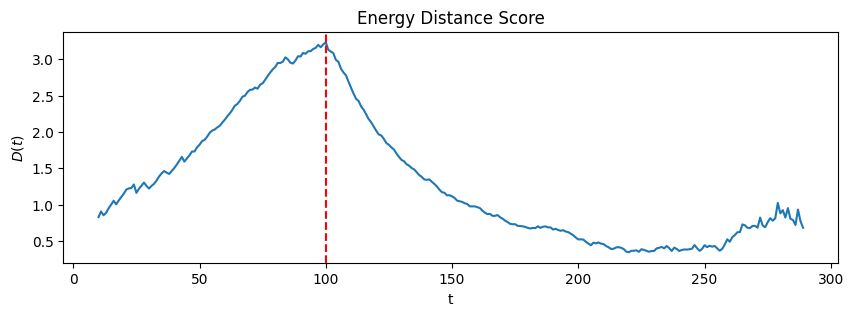

In [22]:
def energy_distance(L, R):
    """Compute energy distance between two 1D arrays"""
    L, R = np.asarray(L), np.asarray(R)
    term1 = 2*np.mean(np.abs(L[:,None] - R[None,:]))
    term2 = np.mean(np.abs(L[:,None] - L[None,:]))
    term3 = np.mean(np.abs(R[:,None] - R[None,:]))
    return term1 - term2 - term3

ts = range(10, len(x)-10)
scores_energy = [energy_distance(x[:t], x[t:]) for t in ts]

t_hat_energy = ts[np.argmax(scores_energy)]
#print(f'Estimated change point (energy distance): {t_hat_energy}')

plt.figure(figsize=(10,3))
plt.plot(ts, scores_energy)
plt.axvline(t_hat_energy, linestyle='--', color='red', label='Estimated CP')
plt.title("Energy Distance Score")
plt.xlabel('t')
plt.ylabel(r'$D(t)$')
plt.show()

In [23]:
np.argmin(scores_energy)

np.int64(210)

However, to actually get the two (or more) candidate change points, we need to recursively divide the list with the energy distances. This is done in the next cell:

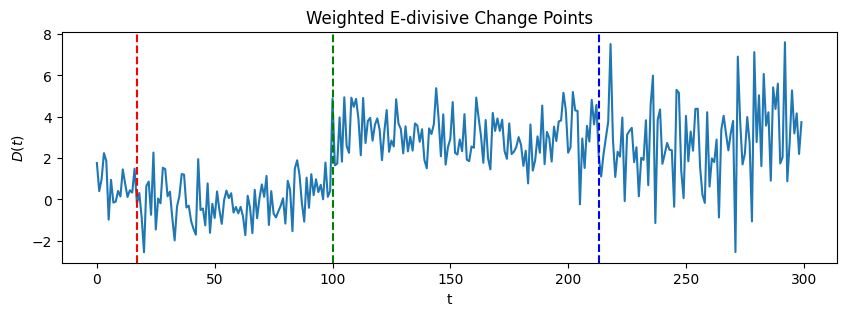

In [28]:
def divisive_energy_weighted(x, max_cp=2, min_size=10):
    """Recursively find change points using size-weighted energy distance"""
    change_points = []

    def _divisive(start, end):
        if len(x[start:end]) < 2*min_size:
            return
        ts = range(start+min_size, end-min_size)
        if not ts:
            return
        
        scores = []
        for t in ts:
            L = x[start:t]
            R = x[t:end]
            weight = len(L)*len(R)/(len(L)+len(R)) # harmonic average
            scores.append(weight * energy_distance(L, R))
        
        t_hat = ts[np.argmax(scores)]
        change_points.append(t_hat)
        if len(change_points) >= max_cp:
            return
            
        _divisive(start, t_hat)
        _divisive(t_hat, end)

    _divisive(0, len(x))
    return sorted(change_points)

# Detect change points
cp_weighted = divisive_energy_weighted(x)
# cp_weighted
# print("Estimated change points (weighted E-divisive):", cp_weighted)

plt.figure(figsize=(10,3))
plt.plot(x)

colors = ['red', 'green', 'blue', 'salmon']
for i, t in enumerate(cp_weighted):
    plt.axvline(t, linestyle='--', color=colors[i], label=f'CP {i+1}' if i==0 else "")

plt.title("Weighted E-divisive Change Points")
plt.xlabel('t')
plt.ylabel(r'$D(t)$')
plt.show()

# Multirank
The Multirank method is conceptually simple and complementary to what we’ve done so far. The main steps consist of:

- Instead of using raw values, replace each data point with its rank in the segment.
- Then compute a contrast score (sum of ranks, or differences in mean ranks) between left and right segments.

The rank of a data point is its position in the ordered sequence of all data points in the segment (or full dataset). Suppose you have a segment of $n$ points: $x_1, x_2, ..., x_n$. Sort the values in ascending order. The smallest value gets rank 1, the second smallest rank 2, …, up to the largest value, which gets rank $n$. So is your segment is `[3.2, 1.5, 4.8, 2.1]`,if you sort this you get `[1.5, 2.1, 3.2, 4.8]`. The ranks thus become `1.5 → 1, 2.1 → 2, 3.2 → 3, 4.8 → 4`, which gives us `[3,1,4,2]`.

This algorithm is robust to outliers and non-Gaussian distributions, because ranks are invariant to monotone transformations.

We can implement a simple rank-based contrast similar to the mean+variance method:

\begin{equation}
D_{rank}(t) = |\bar{r}_L - \bar{r}_R|
\end{equation}

Where $\bar{r}_L$ and $\bar{r}_R$ are the average ranks of the left and right segments, respectively.

Top 4 estimated change points (Multirank): [np.int64(97), np.int64(98), np.int64(99), np.int64(100)]


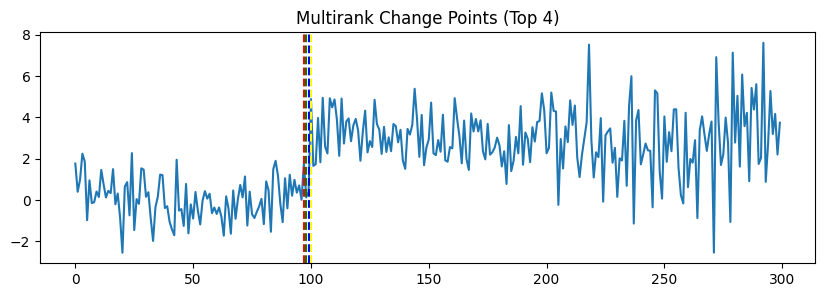

In [33]:
from scipy.stats import rankdata

# Rank the full signal
ranks = rankdata(x)

# Compute simple rank-based contrast across candidate splits
ts = np.arange(10, len(x)-10)
scores_rank = [abs(np.mean(ranks[:t]) - np.mean(ranks[t:])) for t in ts]

# Find top 4 change points
scores_copy = scores_rank.copy()
top_k = 4
cp_rank = []

for _ in range(top_k):
    idx = np.argmax(scores_copy)
    cp_rank.append(ts[idx])
    scores_copy[idx] = 0  # remove this maximum
    #scores_copy[idx-40:idx+40] = [0] *80

cp_rank = sorted(cp_rank)
print("Top 4 estimated change points (Multirank):", cp_rank)

# Plot
plt.figure(figsize=(10,3))
plt.plot(x)

colors = ['red', 'green', 'blue', 'yellow']
for i, t in enumerate(cp_rank):
    plt.axvline(t, linestyle='--', color=colors[i], label=f'CP {i+1}' if i==0 else "")

plt.title("Multirank Change Points (Top 4)")
plt.show()

## Kernel Change Point Detection

Our last algoritm is Kernel Change Point Detection. This algorithm maps our data into a high-dimensional feature space via a kernel, and then detects distributional changes there. This makes it sensitive to any kind of change in the distribution, not just mean, variance, or ranks.

In general, the steps are as follows:

- Pick a kernel $k(x,y)$, e.g. [Gaussian RBF](https://en.wikipedia.org/wiki/Radial_basis_function_kernel).
- Compute the mean embedding of the left and right segments in [RKHS](https://en.wikipedia.org/wiki/Reproducing_kernel_Hilbert_space)
- Compute the squared distance between these embeddings
- Pick the splits with largest $D_{kernel}(t)$.
- For multiple change points, recursively split segments, just like in the weighted E-divisive method.
  

Top 4 estimated change points (Kernel CP): [np.int64(97), np.int64(99), np.int64(100), np.int64(101)]


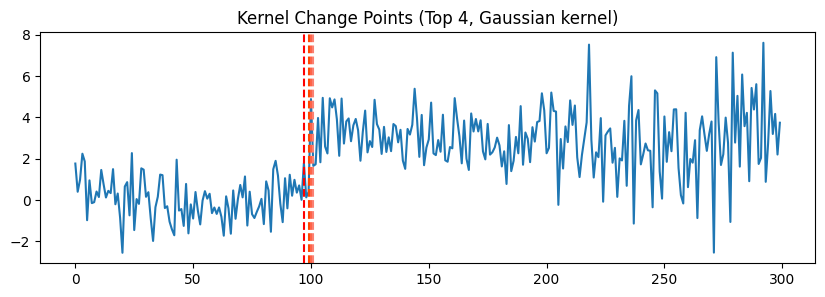

In [34]:
def rbf_kernel(x, y, sigma=1.0):
    return np.exp(-0.5 * ((x - y)/sigma)**2)

def kernel_score(L, R, sigma=1.0):
    # Compute mean embedding squared distance
    K_LL = np.mean(rbf_kernel(L[:,None], L[None,:], sigma))
    K_RR = np.mean(rbf_kernel(R[:,None], R[None,:], sigma))
    K_LR = np.mean(rbf_kernel(L[:,None], R[None,:], sigma))
    return K_LL + K_RR - 2*K_LR

# Compute kernel scores
ts = np.arange(10, len(x)-10)
scores_kernel = np.array([kernel_score(x[:t], x[t:], sigma=1.0) for t in ts])

# Pick top 4 change points (non-recursive for simplicity)
scores_copy = scores_kernel.copy()
top_k = 4
cp_kernel = []

for _ in range(top_k):
    idx = np.argmax(scores_copy)
    cp_kernel.append(ts[idx])
    scores_copy[idx] = 0  

cp_kernel = sorted(cp_kernel)
print(f'Top 4 estimated change points (Kernel CP): {cp_kernel}')

# Plot
plt.figure(figsize=(10,3))
plt.plot(x)

colors = ['red', 'orangered', 'tomato', 'salmon']
for i, t in enumerate(cp_kernel):
    plt.axvline(t, linestyle='--', color=colors[i], label=f'CP {i+1}' if i==0 else "")

plt.title("Kernel Change Points (Top 4, Gaussian kernel)")
plt.show()